# 47 — Motion representations and two-stream networks

A single frame describes appearance, but many video labels depend on change. Lecture 10's two-stream idea separates these signals:

- a **spatial stream** processes image appearance;
- a **temporal stream** processes motion, classically stacks of optical flow;
- their features or class scores are fused.

This notebook uses a controlled four-direction dataset. We begin with frame differences as a simple motion proxy, distinguish them from optical flow, and compare appearance-only, motion-only, and fused models.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F

torch.manual_seed(17)
np.random.seed(17)
CLASS_NAMES = ("right", "left", "down", "up")
DIRECTIONS = torch.tensor([[0, 1], [0, -1], [1, 0], [-1, 0]])

## 1. A direction dataset with an ambiguous middle frame

Each five-frame video contains a bright square moving one pixel per frame. All four classes pass through the same center position at time 2. The middle frame therefore contains no direction information: the classes differ only in what happens before and after it.

The layout is (N,T,C,H,W). Independent low-amplitude background noise makes examples non-identical without deliberately encoding the label.

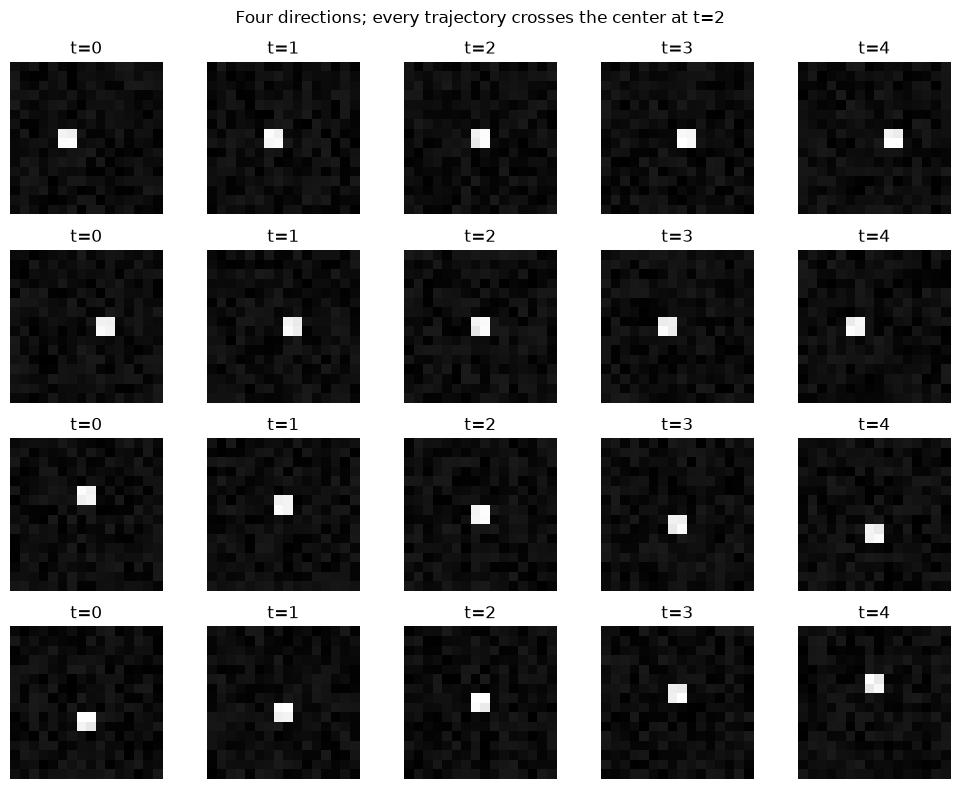

In [3]:
def make_direction_dataset(number_of_examples, seed, image_size=16):
    """Create videos labeled right, left, down, or up."""
    generator = torch.Generator().manual_seed(seed)
    labels = torch.arange(number_of_examples) % 4
    labels = labels[torch.randperm(number_of_examples, generator=generator)]
    videos = 0.1 * torch.rand(
        number_of_examples, 5, 1, image_size, image_size, generator=generator
    )
    middle = image_size // 2 - 1
    for n, label in enumerate(labels):
        row_step, column_step = DIRECTIONS[label]
        for t in range(5):
            offset = t - 2
            row = middle + int(row_step) * offset
            column = middle + int(column_step) * offset
            videos[n, t, 0, row:row + 2, column:column + 2] += 0.9
    return videos.clamp_max(1.0), labels

train_videos, train_labels = make_direction_dataset(400, seed=3)
validation_videos, validation_labels = make_direction_dataset(160, seed=5)
assert train_videos.shape == (400, 5, 1, 16, 16)

example_indices = [
    int(torch.where(train_labels == class_id)[0][0]) for class_id in range(4)
]
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for row, index in enumerate(example_indices):
    for t in range(5):
        axes[row, t].imshow(train_videos[index, t, 0], cmap="gray", vmin=0, vmax=1)
        axes[row, t].set_title(f"t={t}")
        axes[row, t].axis("off")
    axes[row, 0].set_ylabel(CLASS_NAMES[row])
fig.suptitle("Four directions; every trajectory crosses the center at t=2")
plt.tight_layout()
plt.show()

## 2. Temporal frame differences

The difference between consecutive frames is

$$D_t=I_{t+1}-I_t.$$

Positive values show where brightness appeared; negative values show where it disappeared. This exposes local change, but it is **not optical flow**: it does not estimate a displacement vector and is also sensitive to illumination changes.

For videos shaped (N,T,C,H,W), subtract two time-shifted slices. The result has shape (N,T-1,C,H,W).

### Exercise 1 — Calculate and visualize temporal differences

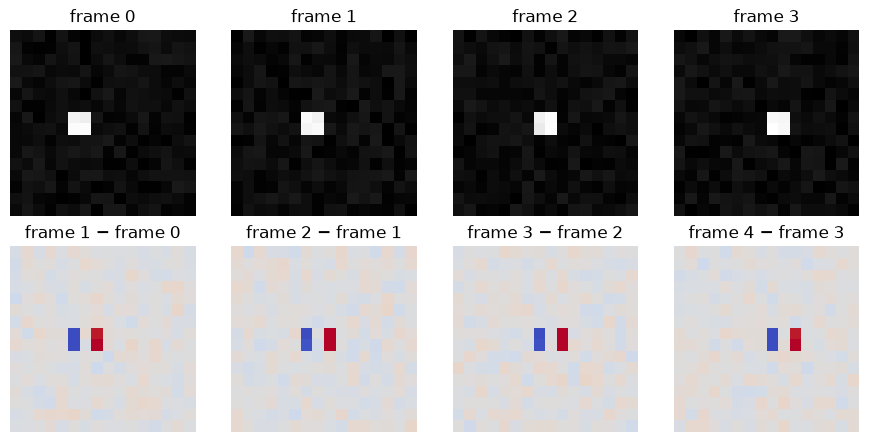

In [4]:
def temporal_difference(videos):
    """Return consecutive next-frame minus current-frame differences."""
    if videos.ndim != 5:
        raise ValueError("videos must have shape (N, T, C, H, W)")
    if videos.shape[1] < 2:
        raise ValueError("videos must contain at least two frames")
    # subtract frames 0..T-2 from frames 1..T-1.
    # differences = videos[:, 1:, :, :, :] - videos[:, :-1, :, :, :]
    differences = videos[:, 1:] - videos[:, :-1]
    return differences

example_video = train_videos[example_indices[0]:example_indices[0] + 1]
example_difference = temporal_difference(example_video)
assert example_difference.shape == (1, 4, 1, 16, 16)

fig, axes = plt.subplots(2, 4, figsize=(9, 4.5))
for t in range(4):
    axes[0, t].imshow(example_video[0, t, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, t].set_title(f"frame {t}")
    axes[1, t].imshow(
        example_difference[0, t, 0], cmap="coolwarm", vmin=-0.9, vmax=0.9
    )
    axes[1, t].set_title(f"frame {t + 1} − frame {t}")
for axis in axes.flat:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 3. Optical-flow intuition

Optical flow estimates a two-dimensional displacement vector at image positions:

$$F(r,c)=(u(r,c),v(r,c)),$$

where $u$ is horizontal displacement and $v$ is vertical displacement. For a square moving right by one pixel, its idealized flow is $(1,0)$ over the object.

A flow field describes where pixels move. A frame difference describes where values changed. A uniform object's flow can be coherent across its surface, while its difference is strongest mainly at entering and leaving edges. Brightness may also change without motion.

Real flow must be estimated and can be uncertain around textureless areas, occlusions, and boundaries. Our synthetic displacement is known, so we construct an idealized field.

### Exercise 2 — Build horizontal and vertical flow fields

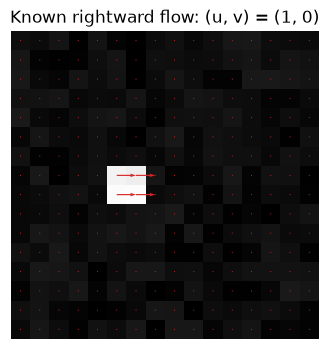

In [5]:
flow_example = train_videos[example_indices[0], 0, 0]
object_mask = flow_example > 0.5

# put horizontal displacement +1 on the moving object.
horizontal_flow = torch.where(object_mask, 1.0, 0.0)
# rightward motion has zero vertical displacement.
vertical_flow = torch.zeros_like(horizontal_flow)

assert horizontal_flow.shape == vertical_flow.shape == (16, 16)
assert torch.all(horizontal_flow[object_mask] == 1)
assert torch.all(vertical_flow == 0)
assert torch.all(horizontal_flow[~object_mask] == 0)

rows, columns = torch.meshgrid(torch.arange(16), torch.arange(16), indexing="ij")
fig, axis = plt.subplots(figsize=(4, 4))
axis.imshow(flow_example, cmap="gray", vmin=0, vmax=1)
axis.quiver(
    columns.numpy(), rows.numpy(),
    horizontal_flow.numpy(), -vertical_flow.numpy(),
    color="tab:red", angles="xy", scale_units="xy", scale=1,
)
axis.set_title("Known rightward flow: (u, v) = (1, 0)")
axis.axis("off")
plt.show()

### Why optical flow is only an intuition here

We can construct this idealized flow field because the synthetic square's displacement is already known. With real frames, pixel motion is unknown and must be estimated by an optical-flow algorithm or a trained model. PyTorch supplies the components needed to build such models, but its core API does not provide one simple general optical-flow operation. Libraries such as [OpenCV](https://docs.opencv.org/) contain classical estimators, while [Torchvision](https://docs.pytorch.org/vision/stable/index.html) provides pretrained models such as RAFT.

Implementing or training a real estimator would be a separate advanced exercise. Here we use consecutive frame differences as a simpler motion representation: they reveal where image values changed, whereas optical flow estimates where pixels moved.

## 4. Prepare the appearance and motion streams

The spatial stream receives only the middle frame. All classes put the square at the same position then, and background noise is independent of the label, so it cannot infer direction reliably.

The temporal stream receives four frame differences. Merge their time and channel axes:

    (N, T-1, C, H, W) → (N, (T-1)C, H, W)

Classical two-stream networks often stack horizontal and vertical optical-flow components instead.

### Exercise 3 — Prepare both stream inputs

In [6]:
(
    train_videos.shape,
    train_videos[:, train_videos.shape[1] // 2].shape,
)


(torch.Size([400, 5, 1, 16, 16]), torch.Size([400, 1, 16, 16]))

In [7]:
def prepare_stream_inputs(videos):
    """Return middle-frame appearance and stacked temporal differences."""
    #  select the middle frame without retaining the time axis.
    appearance = videos[:, videos.shape[1] // 2]
    differences = temporal_difference(videos)
    n, steps, channels, height, width = differences.shape
    # merge steps and channels in their existing order.
    motion = differences.reshape(n, steps*channels, height, width)
    return appearance, motion

appearance_train, motion_train = prepare_stream_inputs(train_videos)
appearance_validation, motion_validation = prepare_stream_inputs(validation_videos)
assert appearance_train.shape == (400, 1, 16, 16)
assert motion_train.shape == (400, 4, 16, 16)

class_means = torch.stack([
    appearance_train[train_labels == class_id].mean(dim=0)
    for class_id in range(4)
])
maximum_class_mean_difference = (
    class_means[:, None] - class_means[None, :]
).abs().max()
print("Largest class-average middle-frame difference:",
      float(maximum_class_mean_difference))

Largest class-average middle-frame difference: 0.014963462948799133


## 5. Feature fusion in a two-stream model

Each stream has its own encoder because its inputs mean different things. Both encoders produce a 16-dimensional feature vector. Feature fusion concatenates them and learns one final classifier.

An alternative is **score fusion**: two complete classifiers produce class scores that are averaged or otherwise combined. Feature fusion lets the final classifier learn interactions between appearance and motion.

### Exercise 4 — Complete the two-stream forward pass

In [8]:
class StreamEncoder(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(input_channels, 12, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(12, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        return self.network(x).flatten(1)


class OneStreamClassifier(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.encoder = StreamEncoder(input_channels)
        self.classifier = nn.Linear(16, 4)

    def forward(self, x):
        return self.classifier(self.encoder(x))


class TwoStreamClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.appearance_encoder = StreamEncoder(1)
        self.motion_encoder = StreamEncoder(4)
        self.classifier = nn.Linear(32, 4)

    def forward(self, appearance, motion):
        # encode each input independently.
        appearance_features = self.appearance_encoder(appearance)
        motion_features = self.motion_encoder(motion)
        # concatenate along the feature dimension.
        fused_features = torch.cat(
            (appearance_features,motion_features), dim=1
        )
        return self.classifier(fused_features)

two_stream = TwoStreamClassifier()
sample_logits = two_stream(appearance_train[:5], motion_train[:5])
assert sample_logits.shape == (5, 4)

## 6. Controlled comparison

We compare:

1. appearance only: the middle frame;
2. motion only: stacked temporal differences;
3. two-stream: concatenated appearance and motion features.

Appearance should stay near four-class chance because we deliberately removed its directional information. Motion should solve the task. Fusion can use motion and should also work, but it need not beat motion-only when appearance adds no useful evidence.

This is an important lesson: adding a stream does not guarantee improvement. It helps when the stream contains complementary information and the model learns to use it.

In [9]:
def train_classifier(model, inputs, labels, iterations=100, learning_rate=2e-2):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    for _ in range(iterations):
        logits = model(*inputs) if isinstance(inputs, tuple) else model(inputs)
        loss = F.cross_entropy(logits, labels)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    return model


def accuracy(model, inputs, labels):
    model.eval()
    with torch.no_grad():
        logits = model(*inputs) if isinstance(inputs, tuple) else model(inputs)
        predictions = logits.argmax(dim=1)
    return float((predictions == labels).float().mean()), predictions


torch.manual_seed(23)
appearance_model = train_classifier(
    OneStreamClassifier(1), appearance_train, train_labels
)
torch.manual_seed(23)
motion_model = train_classifier(
    OneStreamClassifier(4), motion_train, train_labels
)
torch.manual_seed(23)
fused_model = train_classifier(
    TwoStreamClassifier(), (appearance_train, motion_train), train_labels
)

results = {}
for name, model, inputs in (
    ("appearance", appearance_model, appearance_validation),
    ("motion", motion_model, motion_validation),
    ("two-stream", fused_model, (appearance_validation, motion_validation)),
):
    model_accuracy, predictions = accuracy(model, inputs, validation_labels)
    results[name] = (model_accuracy, predictions)
    print(f"{name:>10}: validation accuracy={model_accuracy:.3f}")

assert results["appearance"][0] < 0.40
assert results["motion"][0] > 0.90
assert results["two-stream"][0] > 0.90

appearance: validation accuracy=0.250
    motion: validation accuracy=1.000
two-stream: validation accuracy=1.000


## 7. Compare errors with confusion matrices

Rows represent true classes and columns represent predictions. The appearance model has no reliable directional evidence. Motion-aware models should concentrate counts on the diagonal.

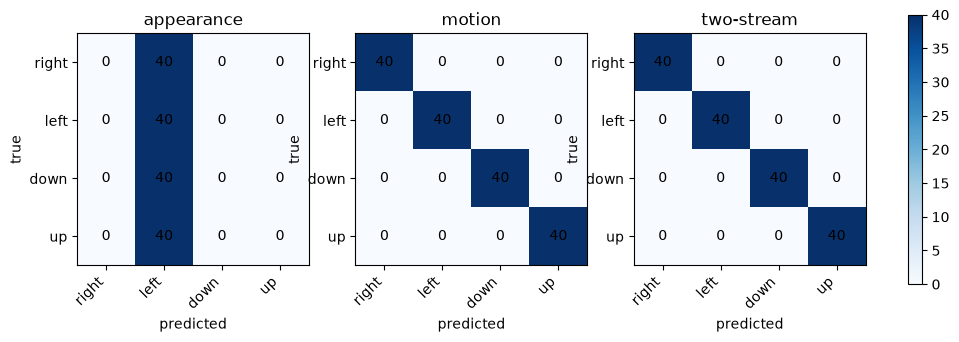

In [10]:
def confusion_matrix(targets, predictions, number_of_classes=4):
    combined = targets * number_of_classes + predictions
    return torch.bincount(
        combined, minlength=number_of_classes**2
    ).reshape(number_of_classes, number_of_classes)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for axis, (name, (_, predictions)) in zip(axes, results.items()):
    matrix = confusion_matrix(validation_labels, predictions)
    image_handle = axis.imshow(matrix, cmap="Blues")
    axis.set_title(name)
    axis.set_xticks(range(4), CLASS_NAMES, rotation=45, ha="right")
    axis.set_yticks(range(4), CLASS_NAMES)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    for row in range(4):
        for column in range(4):
            axis.text(column, row, int(matrix[row, column]), ha="center", va="center")
fig.colorbar(image_handle, ax=axes, fraction=0.025)
plt.show()

## 8. Limitations and modern alternatives

Temporal differences are convenient but do not replace optical flow. Classical two-stream networks often precompute several flow fields, stack horizontal and vertical components, and fuse a temporal network with an RGB network. Flow estimation adds computation and can make errors.

Modern video models may learn motion implicitly using 3D convolutions, recurrent units, temporal attention, or video transformers. The two-stream question remains useful: what information describes appearance, what describes change, and are their errors complementary?

## 9. A harder randomized experiment

The first dataset isolates the central idea, but it is intentionally easy. Here every video receives a random center position and object brightness. Independent frame noise is also much stronger. Direction remains the only class-dependent property: the middle frame still cannot reveal whether the square came from the left, right, above, or below.

This tests whether the motion stream learned a location-independent motion pattern. It also makes temporal differences less clean because subtracting independently noisy frames preserves noise as well as motion. The exact accuracies can vary, and fusion need not beat motion-only when the appearance stream supplies mostly irrelevant evidence.

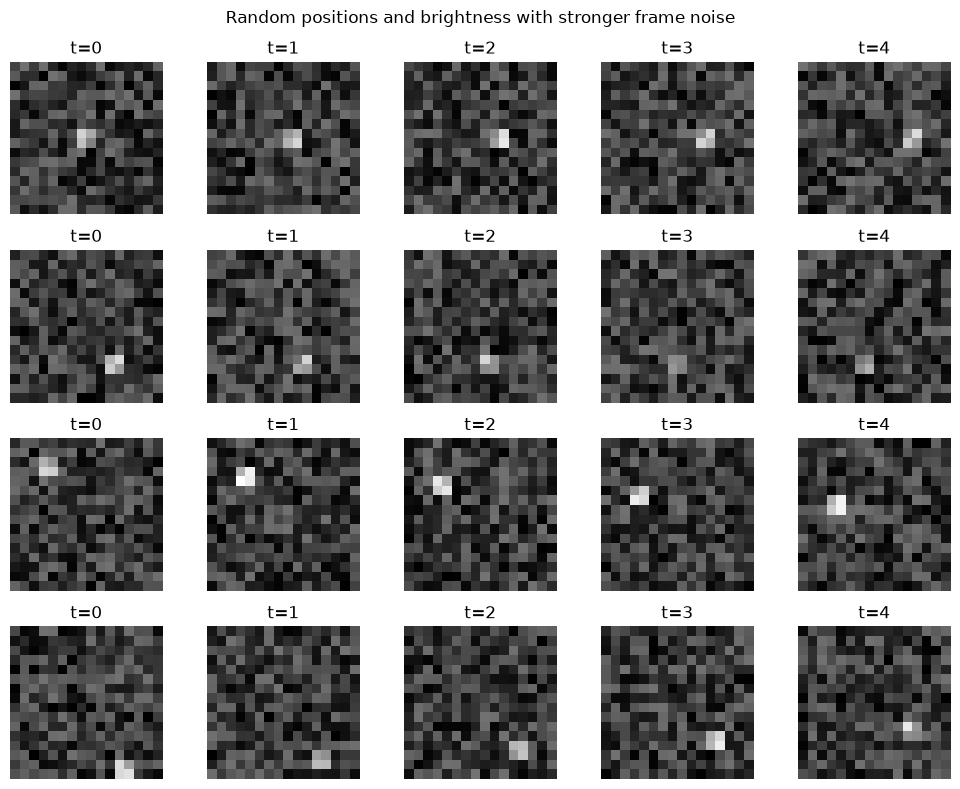

In [11]:
def make_varied_direction_dataset(number_of_examples, seed, image_size=16):
    """Create noisier videos with randomized positions and brightness."""
    generator = torch.Generator().manual_seed(seed)
    labels = torch.arange(number_of_examples) % 4
    labels = labels[torch.randperm(number_of_examples, generator=generator)]

    # Independent noise in every frame makes raw differences noisy too.
    videos = 0.45 * torch.rand(
        number_of_examples, 5, 1, image_size, image_size, generator=generator
    )
    for n, label in enumerate(labels):
        # A margin of two pixels keeps every five-frame path in bounds.
        middle_row = int(torch.randint(2, image_size - 3, (1,), generator=generator))
        middle_column = int(
            torch.randint(2, image_size - 3, (1,), generator=generator)
        )
        brightness = float(
            torch.empty(1).uniform_(0.30, 0.65, generator=generator)
        )
        row_step, column_step = DIRECTIONS[label]
        for t in range(5):
            offset = t - 2
            row = middle_row + int(row_step) * offset
            column = middle_column + int(column_step) * offset
            videos[n, t, 0, row:row + 2, column:column + 2] += brightness

    return videos.clamp_max(1.0), labels


varied_train_videos, varied_train_labels = make_varied_direction_dataset(
    400, seed=31
)
varied_validation_videos, varied_validation_labels = (
    make_varied_direction_dataset(160, seed=37)
)

varied_example_indices = [
    int(torch.where(varied_train_labels == class_id)[0][0])
    for class_id in range(4)
]
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for row, index in enumerate(varied_example_indices):
    for t in range(5):
        axes[row, t].imshow(
            varied_train_videos[index, t, 0], cmap="gray", vmin=0, vmax=1
        )
        axes[row, t].set_title(f"t={t}")
        axes[row, t].axis("off")
    axes[row, 0].set_ylabel(CLASS_NAMES[row])
fig.suptitle("Random positions and brightness with stronger frame noise")
plt.tight_layout()
plt.show()

appearance: validation accuracy=0.262
    motion: validation accuracy=0.956
two-stream: validation accuracy=0.919


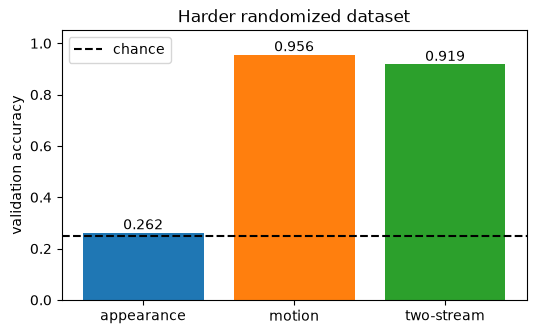

In [12]:
varied_appearance_train, varied_motion_train = prepare_stream_inputs(
    varied_train_videos
)
varied_appearance_validation, varied_motion_validation = prepare_stream_inputs(
    varied_validation_videos
)

varied_setups = (
    ("appearance", lambda: OneStreamClassifier(1),
     varied_appearance_train, varied_appearance_validation),
    ("motion", lambda: OneStreamClassifier(4),
     varied_motion_train, varied_motion_validation),
    ("two-stream", TwoStreamClassifier,
     (varied_appearance_train, varied_motion_train),
     (varied_appearance_validation, varied_motion_validation)),
)

varied_results = {}
for name, make_model, train_inputs, validation_inputs in varied_setups:
    torch.manual_seed(41)
    model = make_model()
    model = train_classifier(
        model, train_inputs, varied_train_labels,
        iterations=80, learning_rate=2e-2,
    )
    model_accuracy, predictions = accuracy(
        model, validation_inputs, varied_validation_labels
    )
    varied_results[name] = (model_accuracy, predictions)
    print(f"{name:>10}: validation accuracy={model_accuracy:.3f}")

names = list(varied_results)
accuracies = [varied_results[name][0] for name in names]
fig, axis = plt.subplots(figsize=(6, 3.5))
bars = axis.bar(names, accuracies, color=("tab:blue", "tab:orange", "tab:green"))
axis.axhline(0.25, color="black", linestyle="--", label="chance")
axis.set_ylim(0, 1.05)
axis.set_ylabel("validation accuracy")
axis.set_title("Harder randomized dataset")
axis.bar_label(bars, fmt="%.3f")
axis.legend()
plt.show()

### Error patterns on the harder dataset

The confusion matrices show which motion directions become confused as noise and appearance variation increase. As before, rows are true classes and columns are predicted classes.

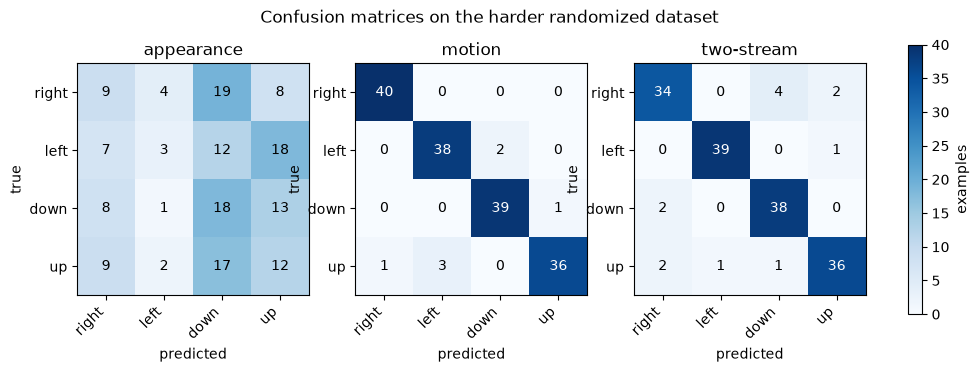

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for axis, (name, (_, predictions)) in zip(axes, varied_results.items()):
    matrix = confusion_matrix(varied_validation_labels, predictions)
    image_handle = axis.imshow(matrix, cmap="Blues", vmin=0, vmax=40)
    axis.set_title(name)
    axis.set_xticks(range(4), CLASS_NAMES, rotation=45, ha="right")
    axis.set_yticks(range(4), CLASS_NAMES)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    for row in range(4):
        for column in range(4):
            count = int(matrix[row, column])
            text_color = "white" if count > 20 else "black"
            axis.text(
                column, row, count, ha="center", va="center",
                color=text_color,
            )
fig.colorbar(image_handle, ax=axes, fraction=0.025, label="examples")
fig.suptitle("Confusion matrices on the harder randomized dataset")
plt.show()

## Reflection

1. What does a positive or negative temporal-difference value mean?
2. Why is a temporal difference not the same as optical flow?
3. What do $u$ and $v$ represent in a flow field?
4. Why can the middle-frame appearance model not solve this task reliably?
5. Why stack several differences rather than use one isolated difference?
6. What is the difference between feature fusion and score fusion?
7. Why does two-stream fusion not necessarily outperform motion-only here?
8. What difficulties arise when using estimated flow on real videos?

### Answers

1. Positive values indicate where brightness appears, negative disappear. positive value means the later frame is brighter at that location; a negative value means it is darker. Motion is one possible cause, but lighting changes can produce the same effect.
2. temporal difference measures pixels differences, optical flow pixel displacement. A temporal difference measures a change in pixel values. Optical flow estimates a displacement vector describing where pixels moved.
3. horizontal and vertical displacement
4. middle frame is static and have no info about movement. The middle frame contains no direction information because every trajectory places the square at the same position, while the background noise is independent of the class.
5. Stacking several differences represents motion over a longer interval and lets the model check whether the direction is consistent across multiple transitions. This can help it distinguish real motion from an isolated noisy change.
6. feature fusion concatenate features of streams and have one classifier layer on top, in case of score fusion there are seprate classifier and final result is average of them. Score fusion combines the outputs of separate classifiers, often—but not necessarily—by averaging.
7. in case apperance stream brings no usefull impact it can bring only additional noise which can have negative impact on results. Irrelevant appearance features can add noise and make optimization or generalization worse. More input information is not automatically useful information.
8. real videos can have textureless areas, boundaries, illumination changes, occlusions, fast motion, motion blur, and camera movement. where it is hard to estimate flow